In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
df=pd.read_csv('height-weight.csv')

In [32]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

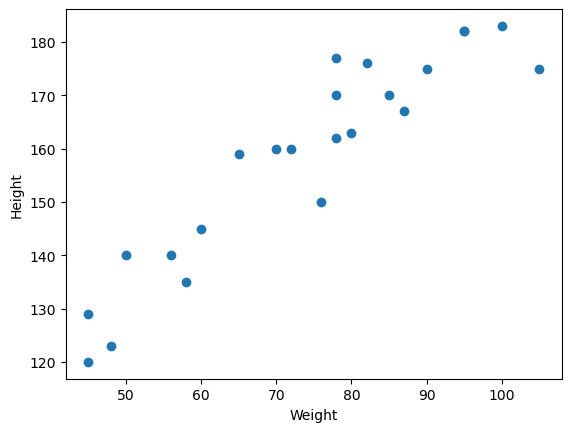

In [33]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

1. divide the features based on indepenent and dependent features
2. do train test split of the dataset - so that we can train our model with training data and test with test data set
3. Standardize the data
4. Train the model using linear regression

In [34]:
###Divide data into independent and dependent features

X=df[['Weight']] ###independent feature
y=df['Height'] ###dependent feature

In [35]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [36]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [37]:
###train test split


from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [38]:
X_train.shape, X_test.shape

((18, 1), (5, 1))

In [39]:
##Standardize the data

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [40]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

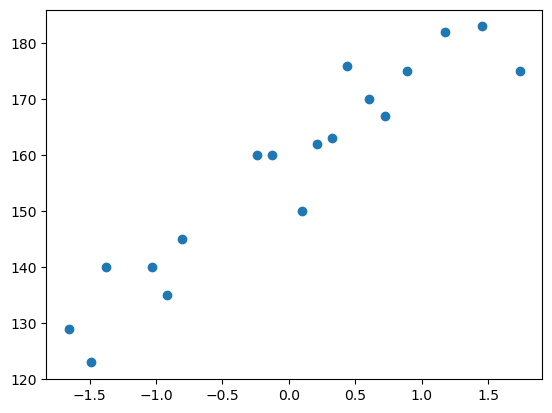

In [41]:
plt.scatter(X_train,y_train)

In [42]:
###Train the model simple linear regression

from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,y_train)




,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
regressor.coef_

array([17.03440872])

In [44]:
regressor.intercept_

np.float64(157.5)

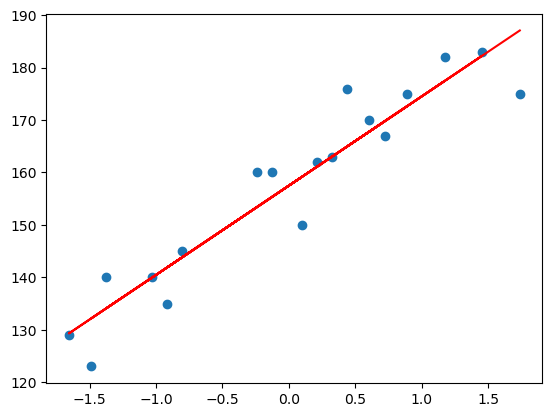

In [45]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),color='red')

prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
#prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [46]:
y_pred_test=regressor.predict(X_test)

In [48]:
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

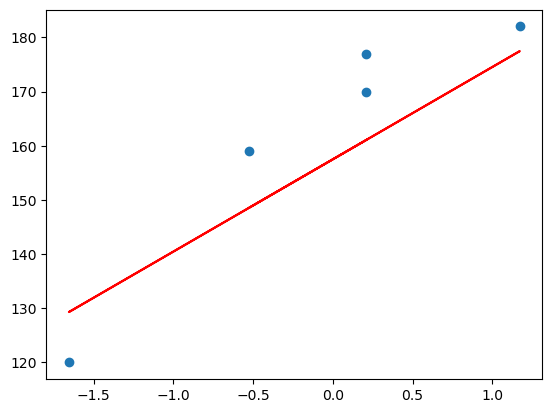

In [49]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

In [52]:
###Performane Metrics

###MSE,MAE,RMSE
###R sqare adjusted R sqaure

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)
score=r2_score(y_test,y_pred_test)
print(score)

109.77592599051654
9.822657814519227
10.477400726827076
0.7769869860423441


In [53]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231254

In [54]:
###new data point


scaled_weight=scaler.transform([[80]])
scaled_weight

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [55]:
regressor.predict(scaled_weight)

array([163.01076266])

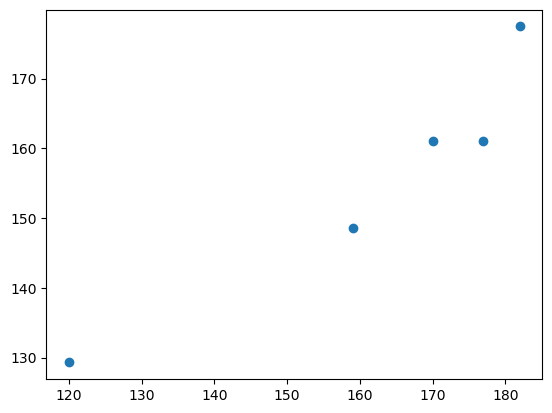

In [56]:
###Assumptions required in linear regression

plt.scatter(y_test,y_pred_test)

In [57]:
###Residuals

####Difference between actual and predicted values

residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

In [58]:
import seaborn as sns

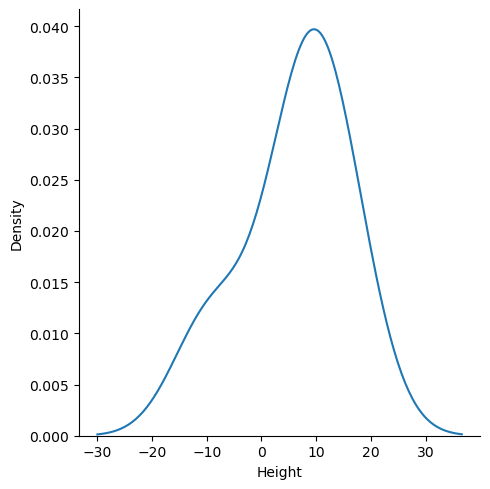

In [59]:
sns.displot(residuals,kind='kde')